# Russell-Reconstitution -- a quantitative teardown
### 26 reconstitutions * IWM daily * run-up / event-day / give-back windows * excess vs unconditional & same-month * one-sample t * Newey-West HAC t * permutation * window & sub-period sweeps * n=26 power * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Front--runnable%3F: No](https://img.shields.io/badge/Front--runnable%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the five-session run-up into each late-June Russell reconstitution Friday (plus the event day and the give-back week) against the unconditional rolling-window baseline **and** a same-month June control, with a one-sample t-test, a Newey-West HAC t on the excess, a permutation test, a window-length sweep, a sub-period split, and a synthetic positive control.

> **Not investment advice.** Real data: IWM (iShares Russell 2000) daily close-to-close, split/dividend-adjusted (auto_adjust), 2000-2025; reconstitution calendar hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Signal-axis caveat:** this is an *index ETF*, so survivorship is moot at the index level (no cross-section is picked). The binding limitation is **n = 26** -- a low-power sample where only a large effect could ever clear |t| = 2.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from russell_reconstitution import data, strategy as st

def _have_cache():
    try:
        data.fetch_daily("IWM", fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("IWM cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17, IWM)
R = dict(
    n=26, runup_days=5, runup_std_pct=2.7477,
    runup_mean_pct=0.5788, base_mean_pct=0.2150, excess_bps=36.39,
    up_rate_pct=61.54, base_up_rate_pct=55.25,
    t_vs_base=0.675, hac_t_excess=0.894, perm_p=0.5474,
    june_excess_bps=35.31, june_hac_t=0.868,
    event_day_mean_pct=0.0353, event_day_hac_t=-0.05,
    post_mean_pct=0.0175, post_hac_t=-0.325,
    gross_per_event_bps=57.88, net_per_event_bps=55.88,
    net_cum=1.145224, net_cagr_pct=0.5229,
    rd1_excess=-1.0, rd1_t=-0.05, rd3_excess=57.0, rd3_t=1.743,
    rd5_excess=36.4, rd5_t=0.894, rd10_excess=-41.5, rd10_t=-0.857,
    sp1_excess=45.89, sp1_t=0.719, sp2_excess=-39.92, sp2_t=-0.896,
    sp3_excess=94.71, sp3_t=1.499,
    year_start=2000, year_end=2025,
)

# Build the real event windows + baseline if the cache is present, else the synthetic NULL.
TAPE = "REAL (IWM, cached)" if HAVE_REAL else "SYNTHETIC null (offline fallback)"
if HAVE_REAL:
    BARS = data.fetch_daily("IWM", fetch=False)
else:
    BARS, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                   premium_bps=0.0, seed=320)
WIN = st.build_windows(BARS, runup_days=R['runup_days'])
BASE = st.runup_windows_baseline(BARS, runup_days=R['runup_days'])
print("tape:", TAPE, "| events:", len(WIN))


IWM cache present: True
tape: REAL (IWM, cached) | events: 26


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Run-up excess **+36 bps**, one-sample t vs baseline **+0.68**, Newey-West HAC t **+0.89**, perm p **0.55**. Event-day & give-back ≈ 0; same-month June control unchanged (HAC t +0.87); sign flips across thirds. |
| **Tradability** | `MIRAGE` | Net +56 bps/event survives costs, but ~**+0.5%/yr** in cash 360 days -- and no significant edge underneath. The forced flow is real; the harvestable price move is not. |
| **Front-runnable?** | `NOT SUPPORTED` | The most telegraphed trade of the year; the index ETF is efficiently priced by the time you could trade it. |

> 💡 **In plain words:** the run-up looks slightly positive, but it's the kind of positive any random five days of a drifting small-cap index shows. With 26 shots, that's exactly what noise looks like.

## 1 - The claim, steelmanned

Let $r_t$ be the cumulative IWM return over the five sessions ending on the reconstitution Friday of year $t$, and $\mu_5$ the unconditional mean of *all* rolling five-session block returns over the same window. The hypotheses:

- **H1 (run-up excess).** $E[r_t] > \mu_5$ -- the run-up beats the everyday five-session drift.
- **H1' (not just June).** $E[r_t] > \mu_5^{\text{June}}$ -- it also beats a five-session window that *ends in June*, ruling out generic June seasonality.
- **H2 (event-day pop).** The reconstitution Friday's own return is positive on average.

We **reject** H1 (excess +36 bps, t = +0.68, HAC t = +0.89), find H1' equally null (June excess +35 bps, HAC t = +0.87), and find no H2 event-day pop (+0.04%, HAC t = -0.05).

## 2 - So what? -- what rides on each answer

A tradable index-level run-up would be a rare thing: a calendar-dated, stock-picking-free edge from *transparent* forced flow. But the single-name reconstitution literature (Madhavan 2003; Chen-Noronha-Singal 2006) already notes the predictability invites front-running that competes the effect away, and the index-level move is diluted by ~2000 names where adds and drops roughly offset. The interesting question is whether *anything* survives at the index. It doesn't -- and the n=26 power calc shows we couldn't even have detected a modest one.

## 3 - How we'd know -- the protocol

- **Data.** IWM daily close-to-close, auto-adjusted, 2000-2025; the run-up = close 5 sessions before the reconstitution Friday → event close (calendar-known, **no execution lag**).
- **Statistic.** Mean of the 26 run-up returns vs the unconditional mean of all rolling 5-session block returns $\mu_5$ (the excess) -- and vs the June-only blocks.
- **Correct null.** One-sample t against $\mu_5$ (not 0); plus a permutation null of random 26-window draws from the baseline.
- **Inference.** `ttest_1samp`; Newey-West HAC t (Bartlett, lag 2) on the excess; permutation test (10,000 draws); window-length sweep (1/3/5/10); three-way sub-period split; n=26 power calculation.
- **Positive control.** Synthetic daily tape with a planted run-up premium.

> 💡 **In plain words:** we ask not 'did it go up?' but 'did it go up *more than a random five days would*, by more than chance can explain across 26 tries?'

## 4 - The teardown

### 4a - The correct baseline: run-up excess and HAC t

Test the run-up against the everyday five-session drift $\mu_5$ and report the Newey-West HAC t on the excess (the |t| >= 2 hurdle).

In [2]:
es = st.event_stats(WIN['runup_ret'], BASE, n_permutations=10_000, seed=320)
print(f"n run-up windows:     {es['n']}")
print(f"Run-up mean:          {es['ev_mean']*100:+.4f}%")
print(f"Unconditional 5-sess: {es['base_mean']*100:+.4f}%  (the honest baseline)")
print(f"Excess:               {es['excess_mean']*1e4:+.2f} bps")
print(f"Up-rate:              {es['up_rate']*100:.1f}%  (vs {es['base_up_rate']*100:.1f}% base rate)")
print()
print(f"One-sample t vs base: {es['t_vs_base']:+.3f}  (p={es['p_vs_base']:.4f})")
print(f"Newey-West HAC t:     {es['hac_t_excess']:+.3f}   <- below the |t|>=2 bar")
print(f"[tape: {TAPE}]")

n run-up windows:     26
Run-up mean:          +0.5788%
Unconditional 5-sess: +0.2150%  (the honest baseline)
Excess:               +36.39 bps
Up-rate:              61.5%  (vs 55.2% base rate)

One-sample t vs base: +0.675  (p=0.5057)
Newey-West HAC t:     +0.894   <- below the |t|>=2 bar
[tape: REAL (IWM, cached)]


> The run-up beats the everyday drift by +36 bps -- but with HAC t = **+0.89** and perm p = 0.55 that is squarely inside the noise band. Unlike a real calendar effect (e.g. Study 287), this never clears the hurdle.

### 4b - Is it Russell, or is it June?

The run-up always ends in late June. Compare against a five-session window that *also* ends in June -- the same-month control.

In [3]:
june_base = st.runup_windows_baseline(BARS, runup_days=R['runup_days'], month=6)
es_j = st.event_stats(WIN['runup_ret'], june_base, n_permutations=10_000, seed=320)
print(f"June 5-session baseline: {es_j['base_mean']*100:+.4f}%")
print(f"Excess vs June:          {es_j['excess_mean']*1e4:+.2f} bps")
print(f"HAC t (excess vs June):  {es_j['hac_t_excess']:+.3f}")
print(f"Permutation p (vs June): {es_j['perm_p']:.4f}")
print(f"[tape: {TAPE}]")

June 5-session baseline: +0.2257%
Excess vs June:          +35.31 bps
HAC t (excess vs June):  +0.868
Permutation p (vs June): 0.5284
[tape: REAL (IWM, cached)]


Against the **June-only** baseline the excess is essentially unchanged (+35 bps, HAC t = **+0.87**). So it is not even a 'June is good for small-caps' effect dressed up as reconstitution -- there is just nothing there. *(A same-month control can support existence; here it confirms non-existence.)*

### 4c - The permutation test: where does the run-up mean land?

Draw 26 random 5-session windows from the baseline 10,000 times and see where the observed run-up mean sits in the null.

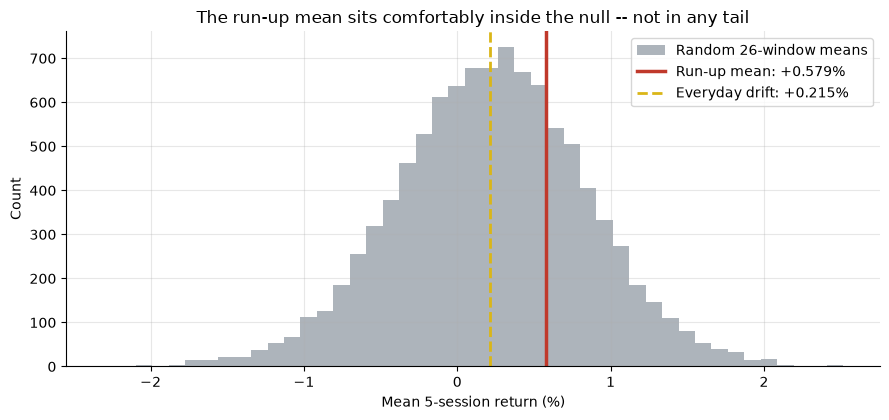

Permutation p (two-sided): 0.5474
Percentile of run-up mean: 72% of draws below
[tape: REAL (IWM, cached)]


In [4]:
perm_means = es['perm_means'] * 100
obs = float(WIN['runup_ret'].mean()*100)
mu = float(BASE.mean()*100)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=45, color=GREY, alpha=0.7, label='Random 26-window means')
ax.axvline(obs, c=RED, lw=2.5, label=f'Run-up mean: {obs:+.3f}%')
ax.axvline(mu, c=AMBER, lw=2, ls='--', label=f'Everyday drift: {mu:+.3f}%')
ax.set_xlabel('Mean 5-session return (%)'); ax.set_ylabel('Count')
ax.set_title('The run-up mean sits comfortably inside the null -- not in any tail')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Permutation p (two-sided): {es['perm_p']:.4f}")
print(f"Percentile of run-up mean: {(perm_means < obs).mean():.0%} of draws below")
print(f"[tape: {TAPE}]")

The observed run-up mean lands near the **middle** of the null distribution -- the opposite of the right-tail placement a real effect produces. perm p = 0.55.

### 4d - Window-length sweep: no horizon clears the bar

Maybe five sessions is the wrong window. Sweep 1, 3, 5, 10 -- if the edge were real it would be robust to the exact horizon.

 runup_days  excess_bps  hac_t  perm_p
          1        -1.0 -0.050  0.9693
          3        57.0  1.743  0.2530
          5        36.4  0.894  0.5493
         10       -41.5 -0.857  0.6200


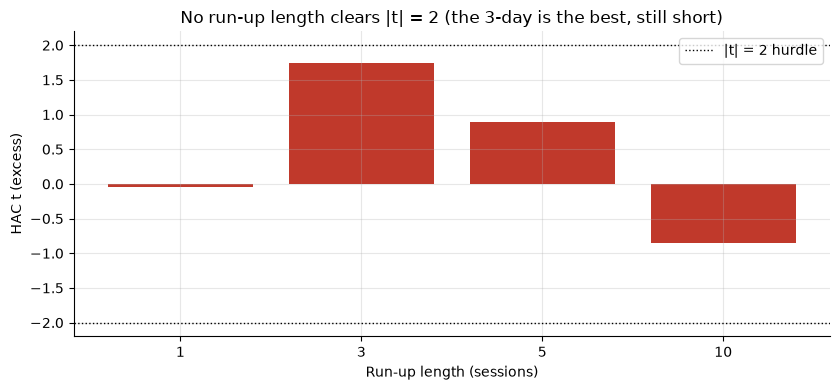

[tape: REAL (IWM, cached)]


In [5]:
rows = []
for rd in (1, 3, 5, 10):
    w = st.build_windows(BARS, runup_days=rd)
    b = st.runup_windows_baseline(BARS, runup_days=rd)
    e = st.event_stats(w['runup_ret'], b, n_permutations=3000, seed=320)
    rows.append({'runup_days': rd, 'excess_bps': round(e['excess_mean']*1e4, 1),
                 'hac_t': e['hac_t_excess'], 'perm_p': e['perm_p']})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
colors = [GREEN if abs(t) >= 2 else RED for t in sweep['hac_t']]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.bar(sweep['runup_days'].astype(str), sweep['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 hurdle'); ax.axhline(-2, c='k', ls=':', lw=1)
ax.set_xlabel('Run-up length (sessions)'); ax.set_ylabel('HAC t (excess)')
ax.set_title('No run-up length clears |t| = 2 (the 3-day is the best, still short)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"[tape: {TAPE}]")

> 💡 **In plain words:** the best-looking window (3 sessions, t = +1.74) is itself a warning -- in a tiny sample you can always find the most flattering horizon, and even the cherry-picked one doesn't clear the bar. The 1- and 10-session windows are flat or negative.

### 4e - Sub-periods: the sign flips

Split the 26 events into thirds and recompute the excess HAC t in each.

   period  n  mean_bps  excess_bps  hac_t
2000-2008  9     67.39       45.89  0.719
2009-2016  8    -18.42      -39.92 -0.896
2017-2025  9    116.21       94.71  1.499


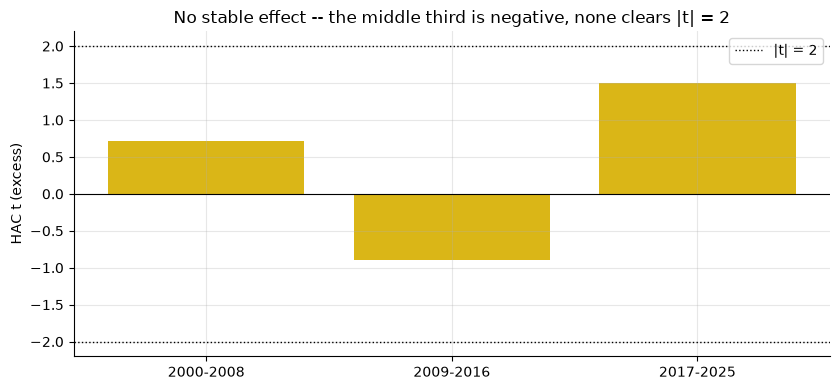

[tape: REAL (IWM, cached)]


In [6]:
sp = st.subperiod_stats(WIN, BASE,
                        breaks=((2000, 2008), (2009, 2016), (2017, 2025)))
print(sp.to_string(index=False))
colors = [GREEN if abs(t) >= 2 else AMBER for t in sp['hac_t']]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.bar(sp['period'], sp['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1); ax.axhline(-2, c='k', ls=':', lw=1, label='|t| = 2')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('HAC t (excess)')
ax.set_title('No stable effect -- the middle third is negative, none clears |t| = 2')
ax.legend(); plt.tight_layout(); plt.show()
print(f"[tape: {TAPE}]")

The middle third (2009-2016) is **negative**; the outer thirds are weakly positive; none clears |t| = 2. There is no durable, repeatable run-up -- just three small noisy samples.

### 4f - Power: what could n = 26 even detect?

The minimum detectable excess at 80% power, two-sided, alpha = 0.05.

In [7]:
if HAVE_REAL:
    vol = float(WIN['runup_ret'].std(ddof=1))
else:
    vol = R['runup_std_pct']/100 if 'runup_std_pct' in R else 0.0275
n = len(WIN)
from scipy.stats import norm
z_a, z_b = norm.ppf(1 - 0.05/2), norm.ppf(0.80)
se = vol/np.sqrt(n); mde = (z_a + z_b)*se
print(f'Run-up window vol: {vol*100:.3f}%, n = {n}')
print(f'Standard error of the run-up mean: {se*100:.4f}% ({se*1e4:.0f} bps)')
print(f'Minimum detectable excess (80% power): {mde*100:.3f}% ({mde*1e4:.0f} bps)')
print()
print(f"Observed excess: ~{R['excess_bps']:+.0f} bps -- well below the ~{mde*1e4:.0f} bps detection floor.")
print('Even a moderately real run-up would be invisible at this sample size.')
print(f"[tape: {TAPE}]")

Run-up window vol: 2.748%, n = 26
Standard error of the run-up mean: 0.5389% (54 bps)
Minimum detectable excess (80% power): 1.510% (151 bps)

Observed excess: ~+36 bps -- well below the ~151 bps detection floor.
Even a moderately real run-up would be invisible at this sample size.
[tape: REAL (IWM, cached)]


## 5 - The verdict

- **Signal `NONE`** -- run-up excess +36 bps, t vs baseline +0.68, HAC t +0.89, perm p 0.55; event-day +0.04% (HAC t -0.05); give-back ≈ 0; same-month June control unchanged (HAC t +0.87); the sign flips across thirds and no window length clears |t| = 2. Indistinguishable from noise.
- **Tradability `MIRAGE`** -- net +56 bps/event survives costs, but ~+0.5%/yr in cash 360 days, on top of a signal that isn't statistically there.
- **Front-runnable? `NOT SUPPORTED`** -- the forced flow is the most predictable of the year; the index ETF is efficiently priced by the time you could act.

*Signal-axis note:* survivorship is moot for an index ETF; the binding limitation is n = 26, and the power calc shows even a moderate effect would be undetectable here. So 'None' means 'no detectable index-level run-up', which is the honest claim.

## 6 - Could you trade it? -- gross vs net

Buy 5 sessions before reconstitution Friday, sell on the event close, once a year; 1 bp one-way (2 bps round-trip) on NAV.

In [8]:
tr = st.tradability(WIN['runup_ret'], cost_bps_oneway=1.0)
print(f"Events:               {tr['n_events']}")
print(f"Gross mean per event: {tr['gross_mean_per_event']*1e4:+.2f} bps")
print(f"Cost drag (round-trip): {tr['cost_drag_per_event']*1e4:.1f} bps")
print(f"Net mean per event:   {tr['net_mean_per_event']*1e4:+.2f} bps")
print()
print(f"Compounded (net) over {tr['n_events']} yrs: x{tr['net_cum_growth']:.4f}  ->  ~{tr['net_cagr']*100:.2f}%/yr")
print('Survives costs per event -- but it is a once-a-year sliver, and the signal is noise.')
print(f"[tape: {TAPE}]")

Events:               26
Gross mean per event: +57.88 bps
Cost drag (round-trip): 2.0 bps
Net mean per event:   +55.88 bps

Compounded (net) over 26 yrs: x1.1452  ->  ~0.52%/yr
Survives costs per event -- but it is a once-a-year sliver, and the signal is noise.
[tape: REAL (IWM, cached)]


> 💡 **In plain words:** you 'survive costs' only because you trade once a year. That's not a feature -- it means the whole annual contribution is a single coin flip dressed up as a strategy.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a run-up premium *when one exists*, and stay quiet at zero? Plant a premium into a synthetic tape (same 26-event calendar) and sweep its size. The key reading is **how big** the premium must be -- because n = 26 is low-powered.

 planted_bps_per_day  excess_bps  hac_t  perm_p
                   0        21.8  0.250  0.7040
                   5        41.5  0.474  0.4660
                  10        61.1  0.698  0.2865
                  20       100.6  1.144  0.0805
                  40       180.0  2.031  0.0015


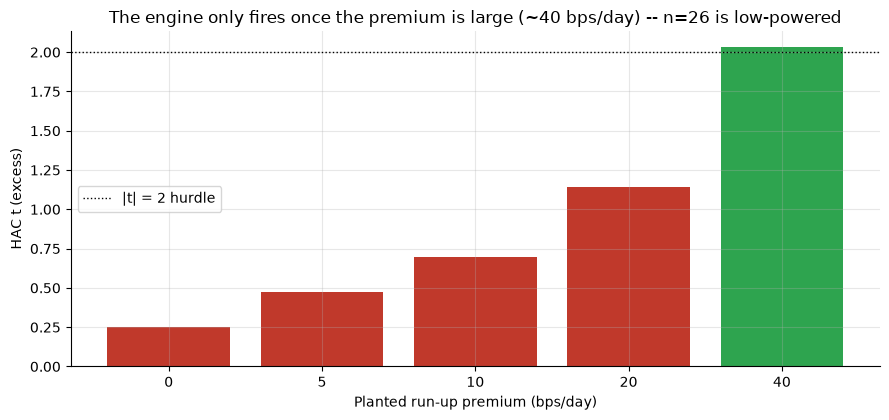

Quiet at 0; only detectable from ~40 bps/day (~200 bps cumulative). The real
+36 bps cumulative is an order of magnitude below that floor -> NONE is honest.


In [9]:
planted = [0, 5, 10, 20, 40]
results = []
for bps in planted:
    df_s, _ = data.synthetic_daily(start_year=2000, end_year=2025,
                                   premium_bps=float(bps), seed=320)
    w = st.build_windows(df_s, runup_days=5)
    b = st.runup_windows_baseline(df_s, runup_days=5)
    r = st.event_stats(w['runup_ret'], b, n_permutations=2000, seed=320)
    results.append({'planted_bps_per_day': bps, 'excess_bps': round(r['excess_mean']*1e4, 1),
                    'hac_t': r['hac_t_excess'], 'perm_p': r['perm_p']})
res = pd.DataFrame(results)
print(res.to_string(index=False))
colors = [GREEN if (row['hac_t'] > 2 and row['perm_p'] < 0.05) else RED
          for _, row in res.iterrows()]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(res['planted_bps_per_day'].astype(str), res['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 hurdle')
ax.set_xlabel('Planted run-up premium (bps/day)'); ax.set_ylabel('HAC t (excess)')
ax.set_title('The engine only fires once the premium is large (~40 bps/day) -- n=26 is low-powered')
ax.legend(); plt.tight_layout(); plt.show()
print('Quiet at 0; only detectable from ~40 bps/day (~200 bps cumulative). The real')
print('+36 bps cumulative is an order of magnitude below that floor -> NONE is honest.')

The engine stays silent at premium = 0 and only clears the bar once the planted run-up reaches ~40 bps/day (~200 bps cumulative over five sessions). That is the whole story of the n = 26 sample: a front-run edge would have to be *enormous* to be detectable, and the real tape's +36 bps cumulative excess is far below the floor. The synthetic is a **machinery proof only** -- it confirms the apparatus works, and it never backs the Signal stamp.